In [20]:
import pandas as pd
import numpy as np

In [21]:
df=pd.read_csv('/content/DSBDA 2 Compusory  - Form responses 1.csv')
print(df)

              Timestamp                    Email address  \
0   28/04/2026 13:38:31      bhansalitejas7498@gmail.com   
1   28/04/2026 13:38:39      yashsurana2005810@gmail.com   
2   28/04/2026 13:38:58      bhansalitejas7498@gmail.com   
3   28/04/2026 13:39:20      yashsurana2005810@gmail.com   
4   28/04/2026 13:39:27      bhansalitejas7498@gmail.com   
5   28/04/2026 13:41:24      yashsurana2005810@gmail.com   
6   28/04/2026 13:41:59              dev264108@gmail.com   
7   28/04/2026 13:42:26      yashsurana2005810@gmail.com   
8   28/04/2026 13:46:00        rushabhshah2410@gmail.com   
9   28/04/2026 13:46:07        shreyapachore06@gmail.com   
10  28/04/2026 13:46:14         siddheshnikumb@gmail.com   
11  28/04/2026 13:46:28         absonawane2006@gmail.com   
12  28/04/2026 13:46:30       prathmeshbagul03@gmail.com   
13  28/04/2026 13:47:16         siddheshnikumb@gmail.com   
14  28/04/2026 13:47:18      bhansalitejas7498@gmail.com   
15  28/04/2026 13:47:35      yashsurana2

In [22]:
 #Identify Missing Values
import pandas as pd

df=pd.read_csv('/content/DSBDA 2 Compusory  - Form responses 1.csv')

print(df.isnull().sum())
print("Total missing:",df.isnull().sum().sum())
print("Shape:",df.shape)

Timestamp                                    0
Email address                                0
Name                                         0
   Roll Number                               0
  Department                                 0
  Year                                       0
  Rate Teaching Quality                      0
 Lab Facilities Rating                       0
  Faculty Support Rating                     0
  Overall Satisfaction                       0
  Suggestions for Improvement               17
   Would You Recommend This Institute?       0
dtype: int64
Total missing: 17
Shape: (31, 12)


In [23]:
#Handle Missing Values
df.columns = df.columns.str.strip()

df["Rate Teaching Quality"]=df["Rate Teaching Quality"].fillna(
df["Rate Teaching Quality"].mean()
)

df["Lab Facilities Rating"]=df["Lab Facilities Rating"].fillna(
df["Lab Facilities Rating"].mean()
)

df["Overall Satisfaction"]=df["Overall Satisfaction"].fillna(
df["Overall Satisfaction"].mode()[0]
)

df["Suggestions for Improvement"]=df[
"Suggestions for Improvement"
].fillna("No Suggestion")

print("Missing after fix:",df.isnull().sum().sum())

Missing after fix: 0


In [24]:
#Remove Duplicate Records
print("Duplicates found:",df.duplicated().sum())

df=df.drop_duplicates()

print("Rows after removing duplicates:",len(df))

Duplicates found: 0
Rows after removing duplicates: 31


In [25]:
#Detect and Handle Outliers (IQR Method)
Q1=df["Rate Teaching Quality"].quantile(0.25)
Q3=df["Rate Teaching Quality"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[
(df["Rate Teaching Quality"]>=lower)&
(df["Rate Teaching Quality"]<=upper)
]

print("Rows after outlier removal:",len(df))

print(
"Teaching Rating Range:",
df["Rate Teaching Quality"].min(),
"-",
df["Rate Teaching Quality"].max()
)

Rows after outlier removal: 31
Teaching Rating Range: 1 - 5


In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

df=pd.read_csv('/content/DSBDA 2 Compusory  - Form responses 1.csv')

print(df.head())

             Timestamp                Email address          Name   \
0  28/04/2026 13:38:31  bhansalitejas7498@gmail.com          Tejas   
1  28/04/2026 13:38:39  yashsurana2005810@gmail.com    Yash surana   
2  28/04/2026 13:38:58  bhansalitejas7498@gmail.com           Anit   
3  28/04/2026 13:39:20  yashsurana2005810@gmail.com  Nirmal chatur   
4  28/04/2026 13:39:27  bhansalitejas7498@gmail.com          Suraj   

      Roll Number     Department        Year      Rate Teaching Quality    \
0                39       Computer  Third Year                          3   
1                22       Computer  Third Year                          5   
2                47       Computer  First Year                          2   
3                25       Computer  Third Year                          4   
4                60     Mechanical  Final Year                          4   

    Lab Facilities Rating     Faculty Support Rating    \
0                        4                           4   


In [27]:
df.columns = df.columns.str.strip()

mapping={
"Excellent":3,
"Good":2,
"Average":1,
"Poor":0
}

df["Satisfaction_Code"]=df["Overall Satisfaction"].map(mapping)

# Features (X)
X=df[[
"Rate Teaching Quality",
"Lab Facilities Rating"
]]

# Target (y)
y=df["Satisfaction_Code"]

print("Features shape:",X.shape)
print("Target shape:",y.shape)

Features shape: (31, 2)
Target shape: (31,)


In [28]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

print("Training samples:",len(X_train))
print("Testing samples:",len(X_test))

Training samples: 24
Testing samples: 7


In [29]:
model=LinearRegression()

model.fit(X_train,y_train)

print("Intercept:",round(model.intercept_,2))

coeff_df=pd.DataFrame({
"Feature":X.columns,
"Coefficient":model.coef_
})

print(coeff_df)

Intercept: -0.01
                 Feature  Coefficient
0  Rate Teaching Quality     0.061768
1  Lab Facilities Rating     0.467119


In [30]:
#Step 5: Evaluate the Model
y_pred=model.predict(X_test)

mse=mean_squared_error(y_test,y_pred)

rmse=np.sqrt(mse)

r2=r2_score(y_test,y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

MSE : 0.44
RMSE : 0.67
R2 Score : 0.6490


In [31]:
#: Sample Prediction
import pandas as pd

new_student = pd.DataFrame({
"Rate Teaching Quality":[5],
"Lab Facilities Rating":[4]
})

predicted = model.predict(new_student)

print(
"Predicted Satisfaction Score:",
round(predicted[0],2)
)

Predicted Satisfaction Score: 2.17


<Axes: xlabel='Overall Satisfaction'>

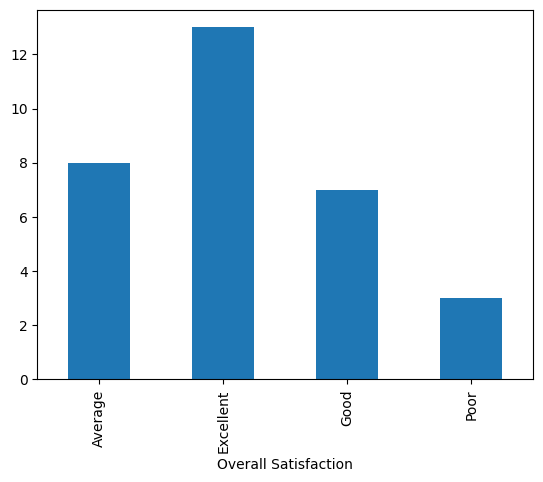

In [32]:
#Bar Chart — Student Satisfaction Distribution
import matplotlib.pyplot as plt

df.groupby("Overall Satisfaction").size().plot(
kind="bar"
)

<Axes: ylabel='count'>

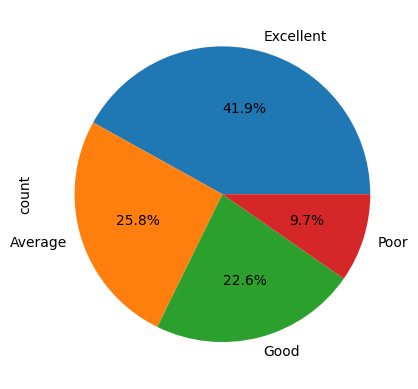

In [33]:
# Pie Chart — Satisfaction Distribution
import matplotlib.pyplot as plt

df["Overall Satisfaction"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

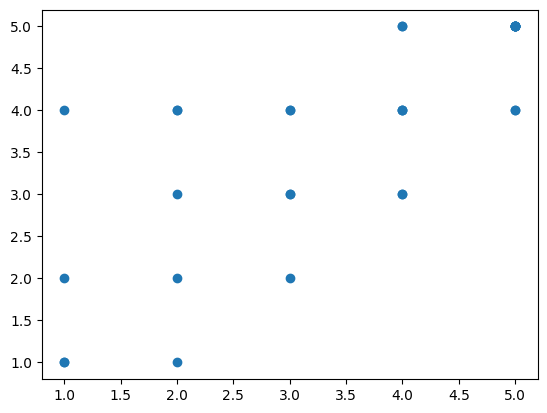

In [34]:
# Scatter Plot — Teaching vs Lab Rating
import matplotlib.pyplot as plt

plt.scatter(
df["Rate Teaching Quality"],
df["Lab Facilities Rating"]
)

<Axes: >

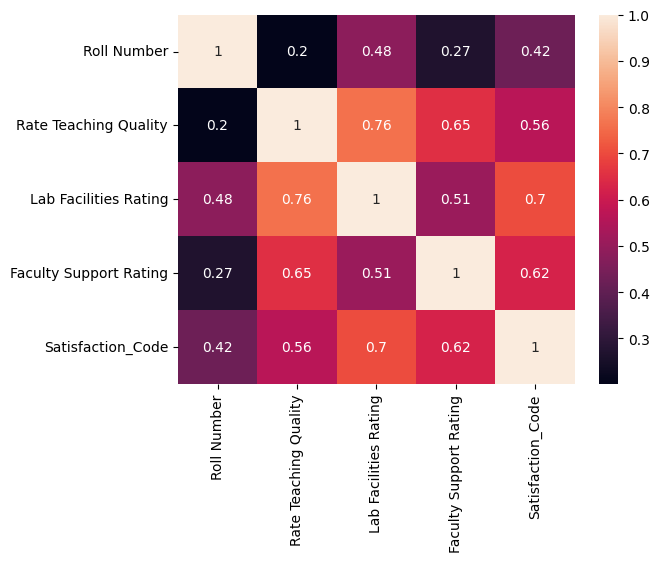

In [35]:
#Heatmap — Feature Correlation (optional extra)
import seaborn as sns

sns.heatmap(
df.corr(numeric_only=True),
annot=True
)

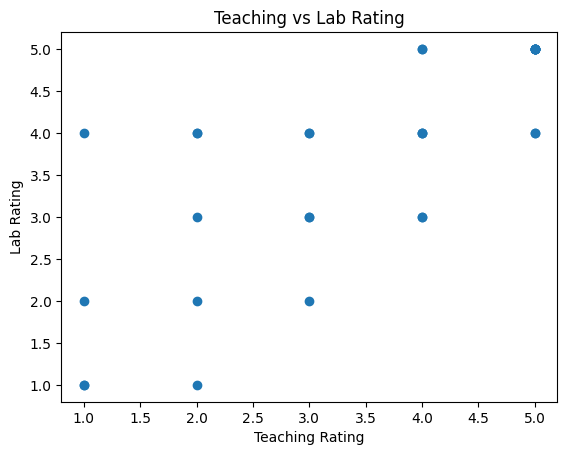

In [36]:
#Scatter Plot
import matplotlib.pyplot as plt

plt.scatter(
df["Rate Teaching Quality"],
df["Lab Facilities Rating"]
)

plt.xlabel("Teaching Rating")
plt.ylabel("Lab Rating")
plt.title("Teaching vs Lab Rating")

plt.show()

<Axes: >

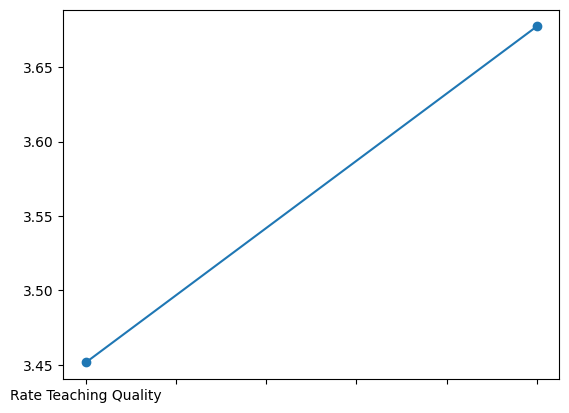

In [37]:
#linechart

import matplotlib.pyplot as plt
ratings = df[[
"Rate Teaching Quality",
"Lab Facilities Rating"
]].mean()

ratings.plot(
kind="line",
marker="o"
)

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Scaled_Teaching']] = scaler.fit_transform(
    df[["Rate Teaching Quality"]])

print(df[["Rate Teaching Quality",'Scaled_Teaching']])

    Rate Teaching Quality  Scaled_Teaching
0                       3             0.50
1                       5             1.00
2                       2             0.25
3                       4             0.75
4                       4             0.75
5                       4             0.75
6                       4             0.75
7                       4             0.75
8                       5             1.00
9                       5             1.00
10                      5             1.00
11                      5             1.00
12                      5             1.00
13                      4             0.75
14                      3             0.50
15                      1             0.00
16                      2             0.25
17                      4             0.75
18                      1             0.00
19                      2             0.25
20                      5             1.00
21                      2             0.25
22         

In [39]:
# Clean dataset
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

df["Rate Teaching Quality"] = df["Rate Teaching Quality"].fillna(
df["Rate Teaching Quality"].mean()
)

df["Lab Facilities Rating"] = df["Lab Facilities Rating"].fillna(
df["Lab Facilities Rating"].mean()
)

df["Overall Satisfaction"] = df["Overall Satisfaction"].fillna(
df["Overall Satisfaction"].mode()[0]
)

df["Department"] = df["Department"].fillna(
df["Department"].mode()[0]
)

df["Suggestions for Improvement"] = df["Suggestions for Improvement"].fillna(
"No Suggestion"
)

print(df.head())

             Timestamp                Email address           Name  \
0  28/04/2026 13:38:31  bhansalitejas7498@gmail.com          Tejas   
1  28/04/2026 13:38:39  yashsurana2005810@gmail.com    Yash surana   
2  28/04/2026 13:38:58  bhansalitejas7498@gmail.com           Anit   
3  28/04/2026 13:39:20  yashsurana2005810@gmail.com  Nirmal chatur   
4  28/04/2026 13:39:27  bhansalitejas7498@gmail.com          Suraj   

   Roll Number  Department        Year  Rate Teaching Quality  \
0           39    Computer  Third Year                      3   
1           22    Computer  Third Year                      5   
2           47    Computer  First Year                      2   
3           25    Computer  Third Year                      4   
4           60  Mechanical  Final Year                      4   

   Lab Facilities Rating  Faculty Support Rating Overall Satisfaction  \
0                      4                       4                 Good   
1                      4                  